##### Promoter Discovery in Bacteria
##### 


##### Preliminaries

In [1]:
# Function to read DNA sequences from a FASTA file
def read_fasta(fasta_file):
    sequences = []
    headers = []
    with open(fasta_file, 'r') as f:
        sequence = ''
        for line in f:
            if line.startswith('>'):
                headers.append(line.strip())  
                if sequence:
                    sequences.append(sequence)
                    sequence = ''
            else:
                sequence += line.strip()
        if sequence:
            sequences.append(sequence)
    return headers, sequences

# Load sequences from the FASTA file
fasta_file = 'CP092752_1.fna' 
headers, sequences = read_fasta(fasta_file)
header=headers[0]
sequence=sequences[0]

print(f"Header: {header}")
print(f"Sequence (first 50 bases): {sequence[:50]}\n")

Header: >CP092752.1 Azotobacter vinelandii strain AEIV chromosome, complete genome
Sequence (first 50 bases): GTGTCCGTGGAACTTTGGCAGCAGTGCGTCGAGCTGCTGCGCGACGAGCT



In [2]:
import gffpandas.gffpandas as gffpd

# Load the GTF file
gtf_file = "CP092752_1.gtf"  
gff_df = gffpd.read_gff3(gtf_file)
# Convert GTF data into a dataframe
gtf_df = gff_df.df

# Display the first few rows of the dataframe
print(gtf_df.head())

       seq_id            source         type  start   end score strand phase  \
0  CP092752.1           Genbank         gene      1  1437     .      +     .   
1  CP092752.1  Protein Homology          CDS      1  1434     .      +     0   
2  CP092752.1  Protein Homology  start_codon      1     3     .      +     0   
3  CP092752.1  Protein Homology   stop_codon   1435  1437     .      +     0   
4  CP092752.1           Genbank         gene   1466  2569     .      +     .   

                                          attributes  
0  gene_id "AVAEIV_000001"; transcript_id ""; gbk...  
1  gene_id "AVAEIV_000001"; transcript_id "unassi...  
2  gene_id "AVAEIV_000001"; transcript_id "unassi...  
3  gene_id "AVAEIV_000001"; transcript_id "unassi...  
4  gene_id "AVAEIV_000002"; transcript_id ""; gbk...  


In [3]:
import numpy as np
sense_strand_genes = gtf_df[(gtf_df['strand'] == '+') & (gtf_df['type'] == 'gene')]
genes_sequences=[]
genes_sequences_w = []
for index, row in sense_strand_genes.iterrows():
    gene_start = int(row['start'])
    gene_end = int(row['end'])
    
    # Extract the sequence of the gene
    gene_seq = sequence[gene_start - 100:gene_start+2]
    genes_sequences.append(gene_seq)
    gene_seq = gene_seq.replace('A', 'W').replace('T', 'W')
    genes_sequences_w.append(gene_seq)

In [4]:
for i in range(1,11):
    print(f"seq{i}:", genes_sequences[i])

seq1: CCGAGCTGCGCGAAACCGACGCGGATATCCGCGAGGACTACAAGAACCTGCTGCGTACCCTGACCACCTGAGCCAGACGCAACCGATTGGGGACTGACCATG
seq2: TCCGACTCCAACAGCAGCGCCTTGCTCCAGGAAGCCGATAATGACGATTCCGCCTATGTCGTCATGCCGATGCGGCTGTAAACCTGCAACCCCGCCTCGATG
seq3: TGAAGCATTGCGTGAAGGCTGGCGCACGGATACGCCAGTTGCCCTGTTCCACGTGGAACAGGGCCGTATCACCCAGACCCACGATCGGGAGTGAAGGTAATG
seq4: CACCGACCAGATCTTCAACACCCTGATGGGCGATGCCGTCGAACCGCGTCGCGAATTCATCGAGAACAACGCGTTGGCGGTGGCGAATCTGGATGTGTGATG
seq5: GAAGTCGCATGTGGCCCTTTGCGACGAGGATTTTCGATTCTGTAACGGCGCCGTTTCTTGCCTAGAATGATCGCTTGTCGACCACACGGAGTCCACGACATG
seq6: CGTAGTCTGGCTCACAAAAATCACCCTGTCCTGAGGCTGCGACGTAAAAGGCTGCGAGTATACCCGATTCCCGGCCCCCTCCACTCTGTGCAAACGCCCATG
seq7: GACCGCCGGAACCCGCTGTCGCTTTTCCGGGCGGAAGGAAGGAAGCCATACGACCGTGCTATCTTGCAGGACCCGGTCCGAGCGCCGATGGAGCGCGCCATG
seq8: TGAGCAGCATTGAAAAAACGGCTTTACGCCGCGATCCGGAGAGAAATCCGGCGGCGCATGACGTTTCATGCGAAGGCACATCATAAAGGGATTCGGCGCATG
seq9: ACTGGCGGTGATGGACAAGGTGCGCAACCCGTAACCTCCGCGTTTTCCCTCCGTCGAGGGAACCGCCTTTCGCTTCCATGGATCAAGGACGATCGCTCCATG
seq10: GCCCGCGAAGGC

##### Local Intact Query

In [5]:
def gap_penalty(k):
    g_alpha = 0
    g_beta = 2
    return -(g_alpha + g_beta * k)

# Match-mismatch scoring function
def prom_base(base_x, base_y, score_m, score_mm):
    if base_x == base_y:
        return score_m
    else:
        return score_mm

# Local alignment scoring matrix for promoter regions
def scorematrix_local(seq_x, seq_y, score_m, score_mm, gap_penalty):
    len_x = len(seq_x)
    len_y = len(seq_y)
    basic_mat = np.zeros((len_x + 1, len_y + 1))

    # Recurrence relation
    for k_x in range(1, len_x + 1):
        for k_y in range(1, len_y + 1):
            score_match = basic_mat[k_x - 1, k_y - 1] + prom_base(seq_x[k_x - 1], seq_y[k_y - 1], score_m, score_mm)
            score_gap_y = basic_mat[k_x, k_y - 1] + gap_penalty(1)
            score_gap_x = basic_mat[k_x - 1, k_y] + gap_penalty(1)
            basic_mat[k_x, k_y] = max(score_match, score_gap_x, score_gap_y, 0)  
    return basic_mat

# Traceback function for local alignment
def traceback_local(seq_x, seq_y, score_m, score_mm, gap_penalty):
    score_matrix = scorematrix_local(seq_x, seq_y, score_m, score_mm, gap_penalty)
    
    len_x = len(seq_x)
    len_y = len(seq_y)
    
    align_x = []
    align_y = []
    
    # Find the maximum score position for local alignment
    max_pos = np.unravel_index(np.argmax(score_matrix, axis=None), score_matrix.shape)
    k_x, k_y = max_pos
    
    # Perform the traceback
    while k_x > 0 and k_y > 0:
        current_score = score_matrix[k_x, k_y]
        diag_score = score_matrix[k_x - 1, k_y - 1]
        gap_x_score = score_matrix[k_x, k_y - 1]
        gap_y_score = score_matrix[k_x - 1, k_y]

        if current_score == diag_score + prom_base(seq_x[k_x - 1], seq_y[k_y - 1], score_m, score_mm):
            align_x.append(seq_x[k_x - 1])
            align_y.append(seq_y[k_y - 1])
            k_x -= 1
            k_y -= 1
        elif current_score == gap_x_score + gap_penalty(1):
            align_x.append('-')
            align_y.append(seq_y[k_y - 1])
            k_y -= 1
        elif current_score == gap_y_score + gap_penalty(1):
            align_x.append(seq_x[k_x - 1])
            align_y.append('-')
            k_x -= 1
        else:
            break
    
    return ''.join(align_x[::-1]), ''.join(align_y[::-1]),score_matrix

# Function to search for promoter regions
def search_promoter_region(genes, promoter_seq, score_m=1, score_mm=-1):
    promoter_hits = 0
    positions = []
    positions_h = []

    for gene in genes:
        positions_i = []
        # Perform traceback to find alignment
        align_x, align_y,score_matrix = traceback_local(gene, promoter_seq, score_m, score_mm, gap_penalty)
        max_score = np.max(score_matrix)
        if max_score > 3:
            start_pos = gene.find(align_x.replace('-', '')) 
        else:
            start_pos = -1
        if start_pos != -1:  # If a valid alignment is found
            promoter_hits += 1
            positions_h.append(start_pos)  
            positions_i.append(start_pos) 
        positions.append(positions_i)

    promoter_percentage = (promoter_hits / len(genes)) * 100
    return promoter_percentage, positions, positions_h

In [6]:
promoter_seq = "WWWW" 
promoter_percentage, positions, positions_h = search_promoter_region(genes_sequences_w, promoter_seq)
print(f"Percentage of genes with potential promoters: {promoter_percentage}%")


Percentage of genes with potential promoters: 72.58464079273328%


In [7]:
print(f"Upstream positions of promoter regions first 20 seq: {positions[:20]}")

Upstream positions of promoter regions first 20 seq: [[], [24], [37], [97], [53], [29], [15], [22], [12], [42], [79], [45], [50], [9], [], [1], [], [77], [7], [29]]


###### output for local intact query for first 20 sequences

In [8]:
for i in range(0,20):
    if len(positions[i]) !=0:
        seq_str=str(genes_sequences[i])
        match=seq_str[positions[i][0]:positions[i][0]+4]
        print(f"seq{i}:", "Promoter Found",match)
    else:
        print(f"seq{i}:", "Promoter Not Found")

seq0: Promoter Not Found
seq1: Promoter Found ATAT
seq2: Promoter Found ATAA
seq3: Promoter Found TAAT
seq4: Promoter Found AATT
seq5: Promoter Found ATTT
seq6: Promoter Found AAAA
seq7: Promoter Found TTTT
seq8: Promoter Found AAAA
seq9: Promoter Found TTTT
seq10: Promoter Found AATT
seq11: Promoter Found TTAT
seq12: Promoter Found AAAA
seq13: Promoter Found TAAT
seq14: Promoter Not Found
seq15: Promoter Found TAAA
seq16: Promoter Not Found
seq17: Promoter Found AAAT
seq18: Promoter Found TTAA
seq19: Promoter Found TATA


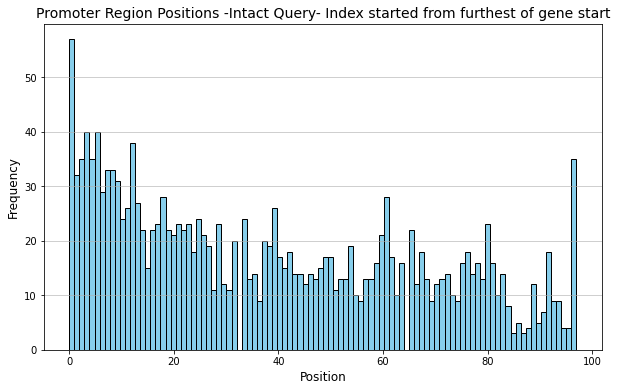

Mean: 38.24687144482366
Standard Deviation: 28.591975391096074


In [9]:
import matplotlib.pyplot as plt
#------Considering positions Satrting from the furthest away from the gene as zero and going in sense direction
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(positions_h, bins=100,color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Promoter Region Positions -Intact Query- Index started from furthest of gene start', fontsize=14)
plt.xlabel('Position', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show grid
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()
print("Mean:", np.mean(positions_h))
print("Standard Deviation:", np.std(positions_h))

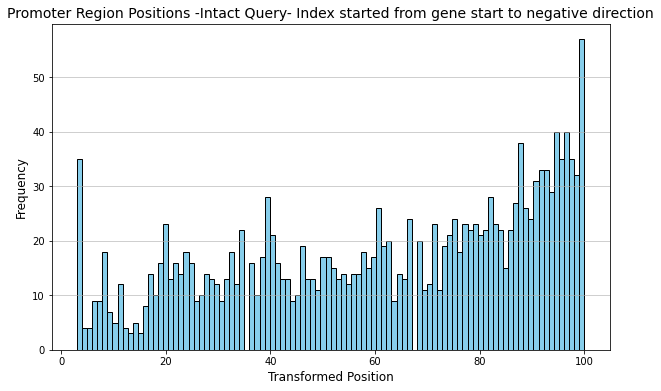

Mean: - 61.75312855517634
Standard Deviation: 28.591975391096074


In [10]:
#----Considering positions Sartting from the starting of the gene as zero and going in anti- sense direction
transformed_positions = (-1) * (np.array(positions_h) - 100)

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(transformed_positions, bins=100, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Promoter Region Positions -Intact Query- Index started from gene start to negative direction', fontsize=14)
plt.xlabel('Transformed Position', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show grid
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.show()
print("Mean: -", np.mean(transformed_positions))
print("Standard Deviation:", np.std(transformed_positions))

##### Number of Consecutive Ws

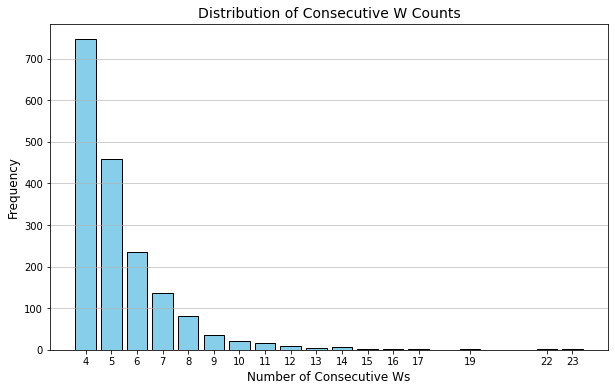

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Function to count consecutive Ws in a sequence
def count_consecutive_Ws(sequence):
    max_count = 0
    current_count = 0  
    for base in sequence:
        if base == 'W':
            current_count += 1
            if current_count > max_count:
                max_count = current_count
        else:
            current_count = 0      
    return max_count

# List to store the counts of consecutive Ws
consecutive_W_counts = []

# Analyze gene sequences for consecutive Ws
for gene_seq in genes_sequences_w:
    if "WWWW" in gene_seq:
        count = count_consecutive_Ws(gene_seq)
        consecutive_W_counts.append(count)

# Calculate distribution of consecutive W counts
count_distribution = Counter(consecutive_W_counts)

# Prepare data for histogram
labels, values = zip(*count_distribution.items())

# Create the histogram
plt.figure(figsize=(10, 6))
plt.bar(labels, values, color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Distribution of Consecutive W Counts', fontsize=14)
plt.xlabel('Number of Consecutive Ws', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show grid
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.xticks(labels)  # Set x-ticks to be the count values
plt.show()

##### Position Probability Matrix

In [12]:
import numpy as np
import pandas as pd

# List to hold the extracted 6-base sequences
extracted_sequences = []

# Extract sequences starting from each position +1 (upstream) and taking 6 bases
for i,pos in enumerate(positions):
    if len(pos)>0:
        start_index = pos[0]   
        if start_index < len(sequence) - 5:  
            extracted_sequences.append(genes_sequences[i][start_index:start_index + 6])

# Convert to DataFrame 
df_sequences = pd.DataFrame(extracted_sequences, columns=['sequence'])

# Initialize the position probability matrix
position_prob_matrix = np.zeros((6, 4))  # 6 positions, 4 bases (A, C, G, T)
# Fill the position probability matrix
for seq in df_sequences['sequence']:
    for i, base in enumerate(seq):
        if base == 'A':
            position_prob_matrix[i, 0] += 1
        elif base == 'C':
            position_prob_matrix[i, 1] += 1
        elif base == 'G':
            position_prob_matrix[i, 2] += 1
        elif base == 'T':
            position_prob_matrix[i, 3] += 1
# Convert counts to probabilities
num_sequences = len(extracted_sequences)
if num_sequences > 0:
    position_prob_matrix = position_prob_matrix / num_sequences

# Display the position probability matrix
position_prob_df = pd.DataFrame(position_prob_matrix, columns=['A', 'C', 'G', 'T'])
position_prob_df.index = [f'Position {i+1}' for i in range(6)]
print(position_prob_df)
#print(extracted_sequences)

                   A         C         G         T
Position 1  0.636519  0.000000  0.000000  0.363481
Position 2  0.525028  0.000000  0.000000  0.474972
Position 3  0.480091  0.000000  0.000000  0.519909
Position 4  0.431741  0.000000  0.000000  0.568259
Position 5  0.176337  0.369170  0.253129  0.201365
Position 6  0.191695  0.366325  0.243458  0.178612


##### Statistical Alignment

In [13]:
import numpy as np
import pandas as pd

# Function to calculate the PPM entropy and information content
def ppm_info(ppm, p0):
    ppm = np.array(ppm)
    p_mat = np.ones_like(ppm) / p0  
    w = np.log(ppm * p_mat + 1e-5)  # Log-transform to avoid log(0)
    su = (ppm * w )/np.log(2)
    return w, su

# Function to get motif scores for a sequence
def get_motif_score(seq, ppm):
    n = len(seq)
    m = ppm.shape[0]
    max_score = float('-inf')
    max_pos = -1
    max_seq = ""
    # Iterate through all possible positions
    for i in range(n - m + 1):
        sub_seq = seq[i:i + m]
        score = get_score(sub_seq, ppm)
        if score > max_score:
            max_score = score
            max_pos = i
            max_seq = sub_seq
    return max_score, max_pos, max_seq

# Function to score a specific sequence using the PPM
def get_score(seq, ppm):
    score = 0
    for i, base in enumerate(seq):
        if base == 'A':
            score += np.log(ppm[i, 0] + 1e-5)
        elif base == 'C':
            score += np.log(ppm[i, 1] + 1e-5)
        elif base == 'G':
            score += np.log(ppm[i, 2] + 1e-5)
        elif base == 'T':
            score += np.log(ppm[i, 3] + 1e-5)
    return score

# Define the promoter scanning function
def scan_promoters(genes_sequences, ppm, score_thresh):
    results = []
    for gene_seq in genes_sequences:
        if len(gene_seq) < ppm.shape[0]:
            continue  
        sm_score, sm_pos, sm_seq = get_motif_score(gene_seq, ppm)
        if sm_score > score_thresh:
            results.append((sm_score, sm_pos, sm_seq))
    return results



#Calculate PPM information
w, su = ppm_info(position_prob_matrix, 0.25)  # Assume uniform background - equiprobable 
net_info_content = np.sum(su, axis=1)
total_info_content = np.sum(net_info_content)

print("Position Probability Matrix (PPM):\n", pd.DataFrame(position_prob_matrix, columns=['A', 'C', 'G', 'T']))
print("\nEntropy (w):\n", w)
print("\nInformation Content (su):\n", su)
print("\nNet Information Content per Position:\n", net_info_content)
print("\nTotal Information Content:\n", total_info_content)

# Step 3: Set threshold and scan promoters
score_thresh = np.min([get_score("TTAACC", position_prob_matrix), get_score("TTAAGG", position_prob_matrix)])
results = scan_promoters(genes_sequences, position_prob_matrix, score_thresh)

total_length = len(genes_sequences)
match_percentage = (len(results) / total_length) * 100
print("------------------------------")
print(f" Match Percentage : {match_percentage} %")
print("------------------------------")


Position Probability Matrix (PPM):
           A         C         G         T
0  0.636519  0.000000  0.000000  0.363481
1  0.525028  0.000000  0.000000  0.474972
2  0.480091  0.000000  0.000000  0.519909
3  0.431741  0.000000  0.000000  0.568259
4  0.176337  0.369170  0.253129  0.201365
5  0.191695  0.366325  0.243458  0.178612

Entropy (w):
 [[  0.93455692 -11.51292546 -11.51292546   0.37427362]
 [  0.74199628 -11.51292546 -11.51292546   0.64179927]
 [  0.65251998 -11.51292546 -11.51292546   0.73219766]
 [  0.54636985 -11.51292546 -11.51292546   0.82112146]
 [ -0.34905124   0.38980177   0.01244644  -0.21632839]
 [ -0.26554175   0.38206783  -0.02650425  -0.33623073]]

Information Content (su):
 [[ 0.85820593 -0.         -0.          0.1962663 ]
 [ 0.56202948 -0.         -0.          0.43978596]
 [ 0.4519516  -0.         -0.          0.54919959]
 [ 0.34031741 -0.         -0.          0.6731759 ]
 [-0.08879869  0.20760804  0.00454528 -0.06284525]
 [-0.07343758  0.20192124 -0.00930926 -0.

In [14]:
print("\nPromoter Scanning Results:")
for sm_score, sm_pos, sm_seq in results:
    print(f"Score: {sm_score:.4f}, Position: {sm_pos}, Matched Sub-Sequence: {sm_seq}")


Promoter Scanning Results:
Score: -4.4958, Position: 24, Matched Sub-Sequence: ATATCC
Score: -5.2306, Position: 78, Matched Sub-Sequence: TAAACC
Score: -4.9635, Position: 53, Matched Sub-Sequence: AATTCA
Score: -5.0222, Position: 29, Matched Sub-Sequence: ATTTTC
Score: -5.0432, Position: 17, Matched Sub-Sequence: AAATCA
Score: -4.9764, Position: 22, Matched Sub-Sequence: TTTTCC
Score: -4.3956, Position: 43, Matched Sub-Sequence: AAATCC
Score: -4.9764, Position: 42, Matched Sub-Sequence: TTTTCC
Score: -4.9764, Position: 82, Matched Sub-Sequence: TTTTCC
Score: -4.7730, Position: 92, Matched Sub-Sequence: AAATGC
Score: -4.6704, Position: 50, Matched Sub-Sequence: AAAACC
Score: -5.2817, Position: 29, Matched Sub-Sequence: ATATGG
Score: -4.3159, Position: 65, Matched Sub-Sequence: AATTCC
Score: -4.7730, Position: 77, Matched Sub-Sequence: AAATGC
Score: -5.3179, Position: 94, Matched Sub-Sequence: AAAACA
Score: -5.3537, Position: 82, Matched Sub-Sequence: TTTTGC
Score: -5.3850, Position: 54

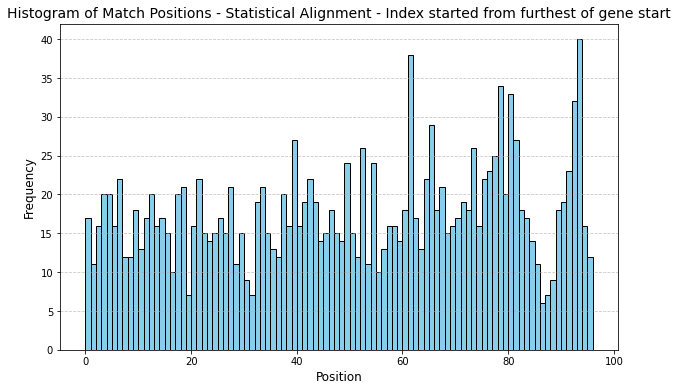

Mean: 49.98178613396005
Standard Deviation: 27.76181252453743


In [15]:
import matplotlib.pyplot as plt

# Extract positions from the results
positions = [sm_pos for _, sm_pos, _ in results]

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(positions, bins=range(min(positions), max(positions) + 1), color='skyblue', edgecolor='black')
plt.title("Histogram of Match Positions - Statistical Alignment - Index started from furthest of gene start", fontsize=14)
plt.xlabel("Position", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Mean:", np.mean(positions))
print("Standard Deviation:", np.std(positions))

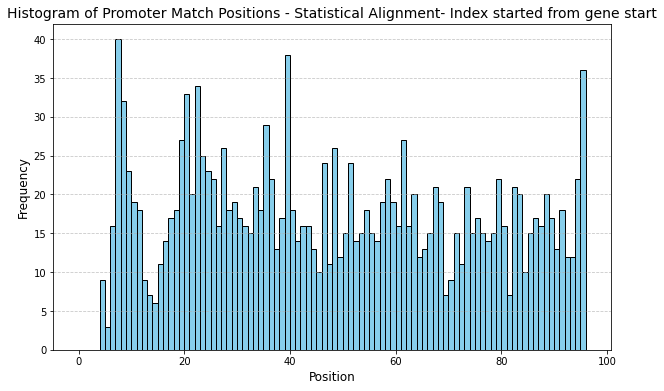

Mean: - 50.01821386603995
Standard Deviation: - 27.76181252453743


In [16]:
import matplotlib.pyplot as plt

# Extract positions from the results
positions = [sm_pos for _, sm_pos, _ in results]
positions_transformed=(-1) * (np.array(positions) - 100)

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(positions_transformed, bins=range(min(positions), max(positions) + 1), color='skyblue', edgecolor='black')
plt.title("Histogram of Promoter Match Positions - Statistical Alignment- Index started from gene start", fontsize=14)
plt.xlabel("Position", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Mean: -", np.mean(positions_transformed))
print("Standard Deviation: -", np.std(positions_transformed))

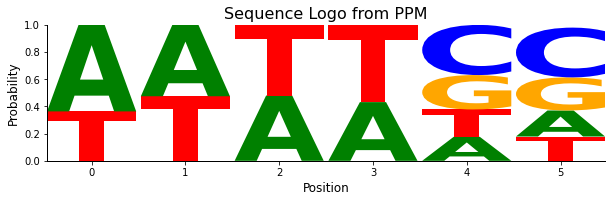

In [17]:
import logomaker
import pandas as pd
import matplotlib.pyplot as plt

position_prob_matrix = position_prob_matrix  
ppm_df = pd.DataFrame(position_prob_matrix, columns=['A', 'C', 'G', 'T'])
# Create a WebLogo
logo = logomaker.Logo(ppm_df, shade_below=.5, fade_below=.5, color_scheme='classic')

# Customize the logo
logo.style_spines(visible=False)
logo.style_spines(spines=['left', 'bottom'], visible=True)
logo.style_xticks(rotation=0, fmt='%d', anchor=0)

# Add labels and a title
plt.title("Sequence Logo from PPM", fontsize=16)
plt.xlabel("Position", fontsize=12)
plt.ylabel("Probability", fontsize=12)

# Display the WebLogo
plt.show()